# Introduction


**File:** Notebook_BVP_to_end.ipynb 
\
**Author:** Elizabeth Gould
\
**Date:** 11.03.2026
\
**Problem:** Find the dependence of the current of a loop on the parameters $B$, $k$, $R$, and $\mu$. 

This Jupyter notebook is used for modeling the relative persistant current $I$ in micrometer scale gold loops which solve the BVP of the nonlinear Schrödinger equation. 

For our observed approximate solution to the nonlinear Schrödinger equation
\begin{equation}
\Psi(x) = e^{i M_{j} x} \left( a e^{i k_{j} x} + b e^{- i k_{j} x} \right),
\end{equation}
we know that $\Psi(0) = \Psi(2\pi R)$ when 
\begin{equation}
\Psi^\prime(0) = i M_{j} + k_j \left( \frac{e^{- 2 i M_{j}\pi R} - \cos\left( 2\pi k_{j} R \right)}{\sin\left(2\pi k_{j} R\right)}\right),
\end{equation}

where $k_{j}\left(\mu, R, B, k_0, \Psi^\prime(0) \right)$ and $M_{j}\left(\mu, R, B, k_0, \Psi^\prime(0) \right)$ are given by our previously solved model. Since the equations for $k_j$ and $M_j$ of our model are dependent on $\Psi^\prime(0)$, we have obtained the values of $\Psi^\prime(0)$ which solve this BVP equation with a numerical root finding algorithm. We now wish to take the task to its conclusion, and determine how the altered solutions change our original solution to the relative current between two rings in the system.

As will be seen, and as should be obvious from our BVP matching condition, the solution to this problem is the same as for the linear case,

\begin{equation}
I_j = - \left| \Psi(0) \right|^2 \frac{\sin\left(2 \pi M_j R_j\right)}{\sin\left(2 \pi k_j R_j\right)},
\end{equation}

where $\Psi(0)$ is our value of $\Psi(x)$ at our point of intersection. This means that our final result for the ratio of current between loops is given by
\begin{equation}
\frac{I_j}{I_n} = \frac{\sin\left(2 \pi M_j R_j\right)\sin\left(2 \pi k_n R_n\right)}{\sin\left(2 \pi k_j R_j\right)\sin\left(2 \pi M_n R_n\right)},
\end{equation}
as was the case for the linear case. Note that our values of $\mu$ in our expressions for $k_j\left(\mu, R_j, B, k_0, \Psi^\prime_j(0) \right)$ and $M_j\left(\mu, R_j, B, k_0, \Psi^\prime_j(0) \right)$ assume $\Psi(0) = 1$, and for the case when $\Psi(0) \neq 1$, the $\mu$ in our results is given by $\mu_{eff} = \mu_{A_0} \left| \Psi(0) \right|^2$, where $\mu_{A_0}$ is the value of $\mu$ which was believed have been provided to the Schrödinger equation.

However, there are a few complications. First, $k_j$ and $M_j$ are now given by a function which depends on $\Psi^\prime(0)$. This means we need a new model for $k_j$ and $M_j$ which solve the BVP rather than which solve the IVP. The second complication is that we don't know $\mu$. More specifically, we don't know how to match $\mu$ between rings -- is $\mu$ effectively equal for equal initial wavefunction, or for equal maximum wavefunction. 

I will proceed by assuming equal $\mu$ for equal initial wavefunction. This is not because this is the result I believe to be the case, but because it is easier, and therefore useful for an initial analysis. As can be seen from our equation for $\mu$, 
\begin{equation}
\mu_{eff} = \mu_{A_0} \left| \Psi(0) \right|^2,
\end{equation}
if $\Psi(0)$ and $\mu_{A_0}$ are both equal for all rings in the system, then $\mu_{eff}$ is also equal for all of the rings, and the solution for relative current can easily be analyzed by just choosing a value for $\mu_{A_0}$ or $\mu_{eff}$.

If we are to believe that instead $\mu$ needs to be matched for equal $\left|\Psi\right|_{max}$, our value of $\mu_{eff}$ is now loop dependent, and given by
\begin{equation}
\mu_{eff} = \mu_{max} \left| \Psi \right|_{max}^2.
\end{equation}
For a fixed $\mu_{max}$, we need to calculate $\mu_{eff, j}$ for every ring by numerically finding the following roots, 
\begin{equation}
0 = \mu_{eff} - \mu_{max} \left| \Psi \right|_{max}^2 = \mu_{eff, j} - \mu_{max} \left(\left| a_j \right|^2 + \left| b_j \right|^2 + 2 \left| a_j \right|\left| b_j \right|\right)
\end{equation}
where
\begin{equation}
a_j = \Psi(0) \frac{1 - e^{i \left(-k_j + M_j \right) 2 \pi R_j}}{e^{i 2 M_j \pi R_j} 2 i \sin \left( 2 \pi k_j R_j \right)},
\end{equation} 

\begin{equation}
b_j = \Psi(0) \frac{-1 + e^{i \left(k_j + M_j \right) 2 \pi R_j}}{e^{i 2 M_j \pi R_j} 2 i \sin \left( 2 \pi k_j R_j \right)},
\end{equation}
and $k_j \left(\mu_{eff,j}, R_j, B, k_0\right)$ and $M_j \left(\mu_{eff,j}, R_j, B, k_0 \right)$ are the values of $k_j\left(\mu_{eff,j}, R_j, B, k_0, \Psi^\prime_j(0) \right)$ and $M_j\left(\mu_{eff,j}, R_j, B, k_0, \Psi^\prime_j(0) \right)$ which solve the BVP.




After demonstrating that our solution is indeed the case, I will, in my next and final notebook, go back to modelling and analyze the dependences of $k_j\left(\mu, R, B, k_0 \right)$ and $M_j\left(\mu, R, B, k_0 \right)$ on the parameters $R$, $B$, $dk$, and $\mu$, with $k_0$ given by $k_0 = k_{Fermi, Au} + dk$.

For completeness, the final boundary matching term is
\begin{equation}
i k_0 \frac{r - 1}{r+1} = i \sum^{n}_{j = 1}k_j\left( a_j \left( 1 - e^{i \left(k_j + M_j\right) 2 \pi R_j} \right) - b_j \left( 1 - e^{i \left(-k_j + M_j\right) 2 \pi R_j}\right) \right).
\end{equation}

Since $\Psi(0) = 1 + r$ in the linear analysis, but $\Psi(0) = 1$ for our analysis, we need to divide by $1+r$. Otherwise the equation is the same, just for new values for $k_j$ and $M_j$. This equation is solved for $r$, which is our reflection coefficent. The analysis is in theory the same as for the linear case, but our right hand side, which is independent of $r$, has a new value. We effectively need to solve the equation
\begin{equation}
\frac{r - 1}{r+1} = W,
\end{equation}
where $W$ is a function of $n$, $k_0$, $B$, $\mu$ and all of our $R_j$ values. This is the same as for the linear case, we have just changed our value $W$. Note, that like the linear case, the complete system, and thus $n$ as well, are unimportant for the analysis of our relative currents.

# Load Grids

We will start, as typical, with our libraries.

In [1]:
# my library
import eelib
from eelib import pi, B_max, phi0inv, R_max

import numpy as np
import pickle
import pandas as pd
import warnings

# machine learning
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# plotting
import matplotlib.pyplot as plt
import seaborn as sns #statistical data visualization


And loading our data from previous runs of our bvp_grid code.

In [2]:
filename = 'grid020'

# loading script; be careful of python version
file = open(filename, 'rb')    
gridl_1 = pickle.load(file)
file.close()

In [3]:
filename = 'grid022'

# loading script; be careful of python version
file = open(filename, 'rb')    
gridl_3 = pickle.load(file)
file.close()

In [4]:
filename = 'grid025'

# loading script; be careful of python version
file = open(filename, 'rb')    
gridl_5 = pickle.load(file)
file.close()

In [5]:
filename = 'grid024'

# loading script; be careful of python version
file = open(filename, 'rb')    
gridl = pickle.load(file)
file.close()

Now to check our objects.

In [6]:
print(gridl_1)
print("")
print(gridl_5)


Grid object to measure current:
mu has 11 points from 1e-10 to 1e-08.
dk has 11 points from 0.51 to 0.515.
B has 11 points from 0.5 to 0.50055.
R has 11 points from 0.9 to 0.90003.
A is: [1.]
k0 is: 12000000000.0
Total number of parameters: 14641

Monte Carlo object to measure current:
mu has points from 1e-07 to 1e-07.
dk has points from 0.51000044582215 to 0.514996169805716.
B has points from 0.5000003637516297 to 0.500549933737302.
R has points from 0.9000000031221171 to 0.9000299973995092.
A has points from 1.0 to 1.0.
k0 has points from 12000000000.0 to 12000000000.0.
Number of points: 1000


In [7]:
print(gridl_3)
print("")
print(gridl)

Grid object to measure current:
mu has 11 points from 1e-10 to 1e-08.
dk has 11 points from 0.1 to 0.9.
B has 11 points from 0.11 to 1.0.
R has 11 points from 0.57 to 1.0.
A is: [1.]
k0 is: 12000000000.0
Total number of parameters: 14641

Grid object to measure current:
mu has 6 points from 1e-10 to 1e-08.
dk has 6 points from 0.51 to 0.515.
B has 6 points from 0.5 to 0.50055.
R has 6 points from 0.9 to 0.90003.
A is: [1.]
k0 is: 12000000000.0
Total number of parameters: 1296


My grids are of the following forms:
 1) gridl_1 is the grid for small parameter changes, as is gridl.
 2) gridl_2 is the Monte Carlo run for small parameter changes, as is grid_5.
 3) gridl_3 is the grid for large parameter changes.
 4) gridl_4 is the Monte Carlo run for large parameter changes.

gridl and gridl_5 are the older, smaller datasets, which is the reason why there are two runs with similar parameters. However, I had accidentally run gridl_2 and gridl_4 with a very small number of parameters, so I have removed them from the code. I didn't redo these runs, as this analysis had since been proven unnecessary. 

Small parameter changes have been chosen to analyze the rapid oscillations, which I know exist in my model. Larger parameter changes attempt to find the large-scale behavior, like slow oscillations or linear depencies. I know they will be ineffective at this task without fully removing the fast oscillations, but I have the data here for trying to determine a starting point of analysis.

# Make Tables

First, load the tables from my objects into pandas dataframes. The data has been saved in my objects in a form of a list of dictionaries, designed to easily form a pandas dataframe with a simple function call.

Tables below can be commented or uncommented as needed.

In [9]:
tbl    = pd.DataFrame(gridl.derivs)
tbl001 = pd.DataFrame(gridl_1.derivs)
#tbl002 = pd.DataFrame(gridl_2.derivs)
tbl003 = pd.DataFrame(gridl_3.derivs)
#tbl004 = pd.DataFrame(gridl_4.derivs)
tbl005 = pd.DataFrame(gridl_5.derivs)

I will also need to get the values of my parameters for grid analyses, so that I can easily select all points with the same value of the given parameter. We also will pull $k  = k_{Fermi, Au}$ and $A = \Psi(0) = 1$.

In [10]:
R_arr = tbl["R"].unique()
B_arr = tbl["B"].unique()
dk_arr = tbl["dk"].unique()
mu_arr = tbl["mu"].unique()
k_val = tbl["k"].unique()[0]
A_val = tbl["A"].unique()[0]

In [11]:
R3_arr = tbl001["R"].unique()
B3_arr = tbl001["B"].unique()
dk3_arr = tbl001["dk"].unique()
mu3_arr = tbl001["mu"].unique()
k_val = tbl001["k"].unique()[0]
A_val = tbl001["A"].unique()[0]

In [12]:
R2_arr = tbl003["R"].unique()
B2_arr = tbl003["B"].unique()
dk2_arr = tbl003["dk"].unique()
mu2_arr = tbl003["mu"].unique()
k_val = tbl003["k"].unique()[0]
A_val = tbl003["A"].unique()[0]

Lets now check to see that the solutions we are given produce the correct final value of $\Psi(2\pi R)$ according to our models for $k_j$ and $M_j$. The values for "New End" and "Exact End" on our table are the values for $\Psi(2\pi R)$ for our nonlinear and linear solutions, respectively. The have been calculated from our model of $\Psi(x)$, for said solution. They have not been calculated with the IVP solver, as the error would make such results meaningless. 

In [13]:
print("(Table 0) Maximum error with ee interaction:   ", np.max(np.abs(tbl["New End"].to_numpy()-(1.0+0.0j))))
print("(Table 0) Maximum error without ee interaction:", np.max(np.abs(tbl["Exact End"].to_numpy()-(1.0+0.0j))))
print("(Table 1) Maximum error with ee interaction:   ", np.max(np.abs(tbl001["New End"].to_numpy()-(1.0+0.0j))))
print("(Table 1) Maximum error without ee interaction:", np.max(np.abs(tbl001["Exact End"].to_numpy()-(1.0+0.0j))))
#print("(Table 2) Maximum error with ee interaction:   ", np.max(np.abs(tbl002["New End"].to_numpy()-(1.0+0.0j))))
#print("(Table 2) Maximum error without ee interaction:", np.max(np.abs(tbl002["Exact End"].to_numpy()-(1.0+0.0j))))
print("(Table 3) Maximum error with ee interaction:   ", np.max(np.abs(tbl003["New End"].to_numpy()-(1.0+0.0j))))
print("(Table 3) Maximum error without ee interaction:", np.max(np.abs(tbl003["Exact End"].to_numpy()-(1.0+0.0j))))
#print("(Table 4) Maximum error with ee interaction:   ", np.max(np.abs(tbl004["New End"].to_numpy()-(1.0+0.0j))))
#print("(Table 4) Maximum error without ee interaction:", np.max(np.abs(tbl004["Exact End"].to_numpy()-(1.0+0.0j))))
print("(Table 5) Maximum error with ee interaction:   ", np.max(np.abs(tbl005["New End"].to_numpy()-(1.0+0.0j))))
print("(Table 5) Maximum error without ee interaction:", np.max(np.abs(tbl005["Exact End"].to_numpy()-(1.0+0.0j))))

(Table 0) Maximum error with ee interaction:    0.00998825640313818
(Table 0) Maximum error without ee interaction: 1.3073150373962005e-10
(Table 1) Maximum error with ee interaction:    0.00999628422114756
(Table 1) Maximum error without ee interaction: 2.470210660871276e-10
(Table 3) Maximum error with ee interaction:    0.009999118362851141
(Table 3) Maximum error without ee interaction: 6.86442258220229e-11
(Table 5) Maximum error with ee interaction:    0.00997567727459663
(Table 5) Maximum error without ee interaction: 1.7774866325471916e-09


Now to dump the unneeded data from the tables.

From previous analysis, I know that "I v2" is the best version of my calculation for the current of the nonlinear solution. This value is equal to the "I v3" current, which is calculated at our initial position, using the full equation for $I_j$,
\begin{equation}
I_j = \frac{1}{2 k_0 i}\left( \overline{\psi_j} \frac{d}{dx} \psi_j -\psi_j \overline{\frac{d}{dx} \psi_j} -i \frac{2 B \pi R_j}{\Phi_0} \overline{\psi_j}  \psi_j  \right),
\end{equation}
with our known $\psi(0)$ and $\psi^\prime(0)$ values. We will thus remove "I v1" and "I v3" from our table. 

$k$ and $A$ are unnecessary as they are always identical. After I have checked "Exact End" and "New End", they are no longer required. That leaves 4 independent variables and 11 dependent variables. Note that here there is still unnecesary data, but at this point I don't know it is unnecesary.

In [14]:
tbl2   =    tbl[["R", "B", "dk", "mu", 'dpsi0', 'a0', 'b0', 'A max 0', 'I0', 'dpsi', 'a', 'b', 'A max new', 'I v2', 'effective mu']]
tbl011 = tbl001[["R", "B", "dk", "mu", 'dpsi0', 'a0', 'b0', 'A max 0', 'I0', 'dpsi', 'a', 'b', 'A max new', 'I v2', 'effective mu']]
#tbl012 = tbl002[["R", "B", "dk", "mu", 'dpsi0', 'a0', 'b0', 'A max 0', 'I0', 'dpsi', 'a', 'b', 'A max new', 'I v2', 'effective mu']]
tbl013 = tbl003[["R", "B", "dk", "mu", 'dpsi0', 'a0', 'b0', 'A max 0', 'I0', 'dpsi', 'a', 'b', 'A max new', 'I v2', 'effective mu']]
#tbl014 = tbl004[["R", "B", "dk", "mu", 'dpsi0', 'a0', 'b0', 'A max 0', 'I0', 'dpsi', 'a', 'b', 'A max new', 'I v2', 'effective mu']]
tbl015 = tbl005[["R", "B", "dk", "mu", 'dpsi0', 'a0', 'b0', 'A max 0', 'I0', 'dpsi', 'a', 'b', 'A max new', 'I v2', 'effective mu']]

The next step is to clear the table of all the unneeded high energy solutions, as I need to only keep the lowest energy solution for every set of parameters. I will define functions to create new dataframes out of the desired solution, then run these functions for all of my dataframes.

In [15]:
# My whole script to create a new cleaned table is given here.
# Note that this works with the Monte Carlo variants, but it is too slow and ineffective.
def clean_table(tbl):
    val_list = [] # Create a list, in which to store all the rows we wish to keep.
    R_arr = tbl["R"].unique()
    for rr in R_arr:
        B_arr = tbl["B"].unique()
        for bb in B_arr:
            dk_arr = tbl['dk'].unique()
            for kk in dk_arr:
                mu_arr = tbl['mu'].unique()
                for mm in mu_arr:
                    # For each such sets of parameters, select all rows which share this set of parameters.
                    tbl_select = tbl[(tbl["R"] == rr)&(tbl["B"] == bb)&(tbl["dk"] == kk)&(tbl["mu"]==mm)]
                    # Within the try statement is code to select the best of the rows and add it to my 
                    # val_list list. It is contained in a try statement so that if there are no such rows,
                    # it will just ignore this and not add anything to the list.
                    try:
                        ll = np.min(list(tbl_select["A max new"])) # select the row with the lowest max amplitude
                        tbl_row = tbl_select[tbl_select["A max new"]==ll].values.tolist() # extract the data from the row
                        val_list.append(tbl_row[0]) # and add it to my list of saved rows
                    except ValueError:
                        pass # add nothing and continue to the next parameter set if there are no values with the given parameters

    # A list of the names of my columns to use when creating a dataframe
    col_names = ["R", "B", "dk", "mu", 'dpsi0', 'a0', 'b0', 'A max 0', 'I0', 'dpsi', 'a', 'b', 'A max new', 'I v2', 'effective mu']

    # Now create a new dataframe with my desired rows and the given column names.
    # A list of equal sized lists is another valid data format for creating a dataframe.
    new_tbl = pd.DataFrame(val_list, columns=col_names)

    # Recast all of our real values as real numbers, as due to the existance of complex values for some 
    # columns, the real column had been recast as complex numbers when extracting the data.
    # Recasting complex numbers as real numbers gives a warning, but the numbers being recast here
    # were originally real numbers which had been recast as complex, so I can safely ignore this warning.
    with warnings.catch_warnings(action="ignore"):
        new_tbl['R'] = new_tbl['R'].astype(float)
        new_tbl['B'] = new_tbl['B'].astype(float)
        new_tbl['dk'] = new_tbl['dk'].astype(float)
        new_tbl['mu'] = new_tbl['mu'].astype(float)
        new_tbl['A max 0'] = new_tbl['A max 0'].astype(float)
        new_tbl['I0'] = new_tbl['I0'].astype(float)
        new_tbl['A max new'] = new_tbl['A max new'].astype(float)
        new_tbl['I v2'] = new_tbl['I v2'].astype(float)
        new_tbl['effective mu'] = new_tbl['effective mu'].astype(float)

    # Return the resulting dataframe. Our result is a new dataframe, not a splice (which will be an important fact later).
    return new_tbl


In [16]:
# This is the same script, but in a form which takes account of the fact that Monte Carlo algorithms will 
# have all new parameters. I will only examine one parameter, selecting all rows with equal values for that 
# parameter, and saving the best of them. If applied to a grid of data, this algorithm will throw out the
# grid, but for Monte Carlo datasets, the chance of loosing a desired data point is very small.
def clean_table_MC(tbl):
    val_list = [] # Create a list, in which to store all the rows we wish to keep.
    R_arr = tbl["R"].unique()
    for rr in R_arr:
        # For each such sets of parameters, select all rows which share this set of parameters.
        tbl_select = tbl[tbl["R"] == rr] 
        ll = np.min(list(tbl_select["A max new"])) # select the row with the lowest max amplitude
        tbl_row = tbl_select[tbl_select["A max new"]==ll].values.tolist() # extract the data from the row
        val_list.append(tbl_row[0]) # and add it to my list of saved rows

    # A list of the names of my columns to use when creating a dataframe
    col_names = ["R", "B", "dk", "mu", 'dpsi0', 'a0', 'b0', 'A max 0', 'I0', 'dpsi', 'a', 'b', 'A max new', 'I v2', 'effective mu']#, columns = col_names
    
    # Now create a new dataframe with my desired rows and the given column names.
    # A list of equal sized lists is another valid data format for creating a dataframe.
    new_tbl = pd.DataFrame(val_list, columns=col_names)

    # Recast all of our real values as real numbers, as due to the existance of complex values for some 
    # columns, the real column had been recast as complex numbers when extracting the data.
    # Recasting complex numbers as real numbers gives a warning, but the numbers being recast here
    # were originally real numbers which had been recast as complex, so I can safely ignore this warning.
    with warnings.catch_warnings(action="ignore"):
        new_tbl['R'] = new_tbl['R'].astype(float)
        new_tbl['B'] = new_tbl['B'].astype(float)
        new_tbl['dk'] = new_tbl['dk'].astype(float)
        new_tbl['mu'] = new_tbl['mu'].astype(float)
        new_tbl['A max 0'] = new_tbl['A max 0'].astype(float)
        new_tbl['I0'] = new_tbl['I0'].astype(float)
        new_tbl['A max new'] = new_tbl['A max new'].astype(float)
        new_tbl['I v2'] = new_tbl['I v2'].astype(float)
        new_tbl['effective mu'] = new_tbl['effective mu'].astype(float)
    
    # Return the resulting dataframe. Our result is a new dataframe, not a splice (which will be an important fact later).
    return new_tbl

In [17]:
tbl021 = clean_table(tbl011)
tbl023 = clean_table(tbl013)

In [18]:
# Monte Carlo data must be done with the Monte Carlo version of the algorithm, due to time constraints.

#tbl022 = clean_table_MC(tbl012)
#tbl024 = clean_table_MC(tbl014)
tbl025 = clean_table_MC(tbl015)

In [19]:
new_tbl = clean_table(tbl2)

And a test of just one of these dataframes.

In [20]:
tbl021.head()

,R,B,dk,mu,dpsi0,a0,b0,A max 0,I0,dpsi,a,b,A max new,I v2,effective mu
0,0.9,0.5,0.51,1.000000e-10,1.054613e+10+4.462116e+ 07j,0.501674-0.439413j,0.498326+0.439413j,1.331292,0.003348,1.052821e+10+4.460161e+ 07j,0.501673-0.438666j,0.498327+0.438666j,1.330307,0.003346,1.769717e-10
1,0.9,0.5,0.51,1.584893e-10,1.054613e+10+4.462116e+ 07j,0.501674-0.439413j,0.498326+0.439413j,1.331292,0.003348,1.051777e+10+4.459022e+ 07j,0.501673-0.438231j,0.498327+0.438231j,1.329733,0.003345,2.802394e-10
2,0.9,0.5,0.51,2.511886e-10,1.054613e+10+4.462116e+ 07j,0.501674-0.439413j,0.498326+0.439413j,1.331292,0.003348,1.050128e+10+4.457225e+ 07j,0.501672-0.437544j,0.498328+0.437544j,1.328828,0.003344,4.435448e-10
3,0.9,0.5,0.51,3.981072e-10,1.054613e+10+4.462116e+ 07j,0.501674-0.439413j,0.498326+0.439413j,1.331292,0.003348,1.047527e+10+4.454395e+ 07j,0.501671-0.436460j,0.498329+0.436460j,1.327402,0.003342,7.014631e-10
4,0.9,0.5,0.51,6.309573e-10,1.054613e+10+4.462116e+ 07j,0.501674-0.439413j,0.498326+0.439413j,1.331292,0.003348,1.043440e+10+4.449953e+ 07j,0.501669-0.434757j,0.498331+0.434757j,1.325164,0.003338,1.107999e-09


# Triangle Plots

Now for the triangle plots. This is section is designed to get a sense of what we are dealing with.

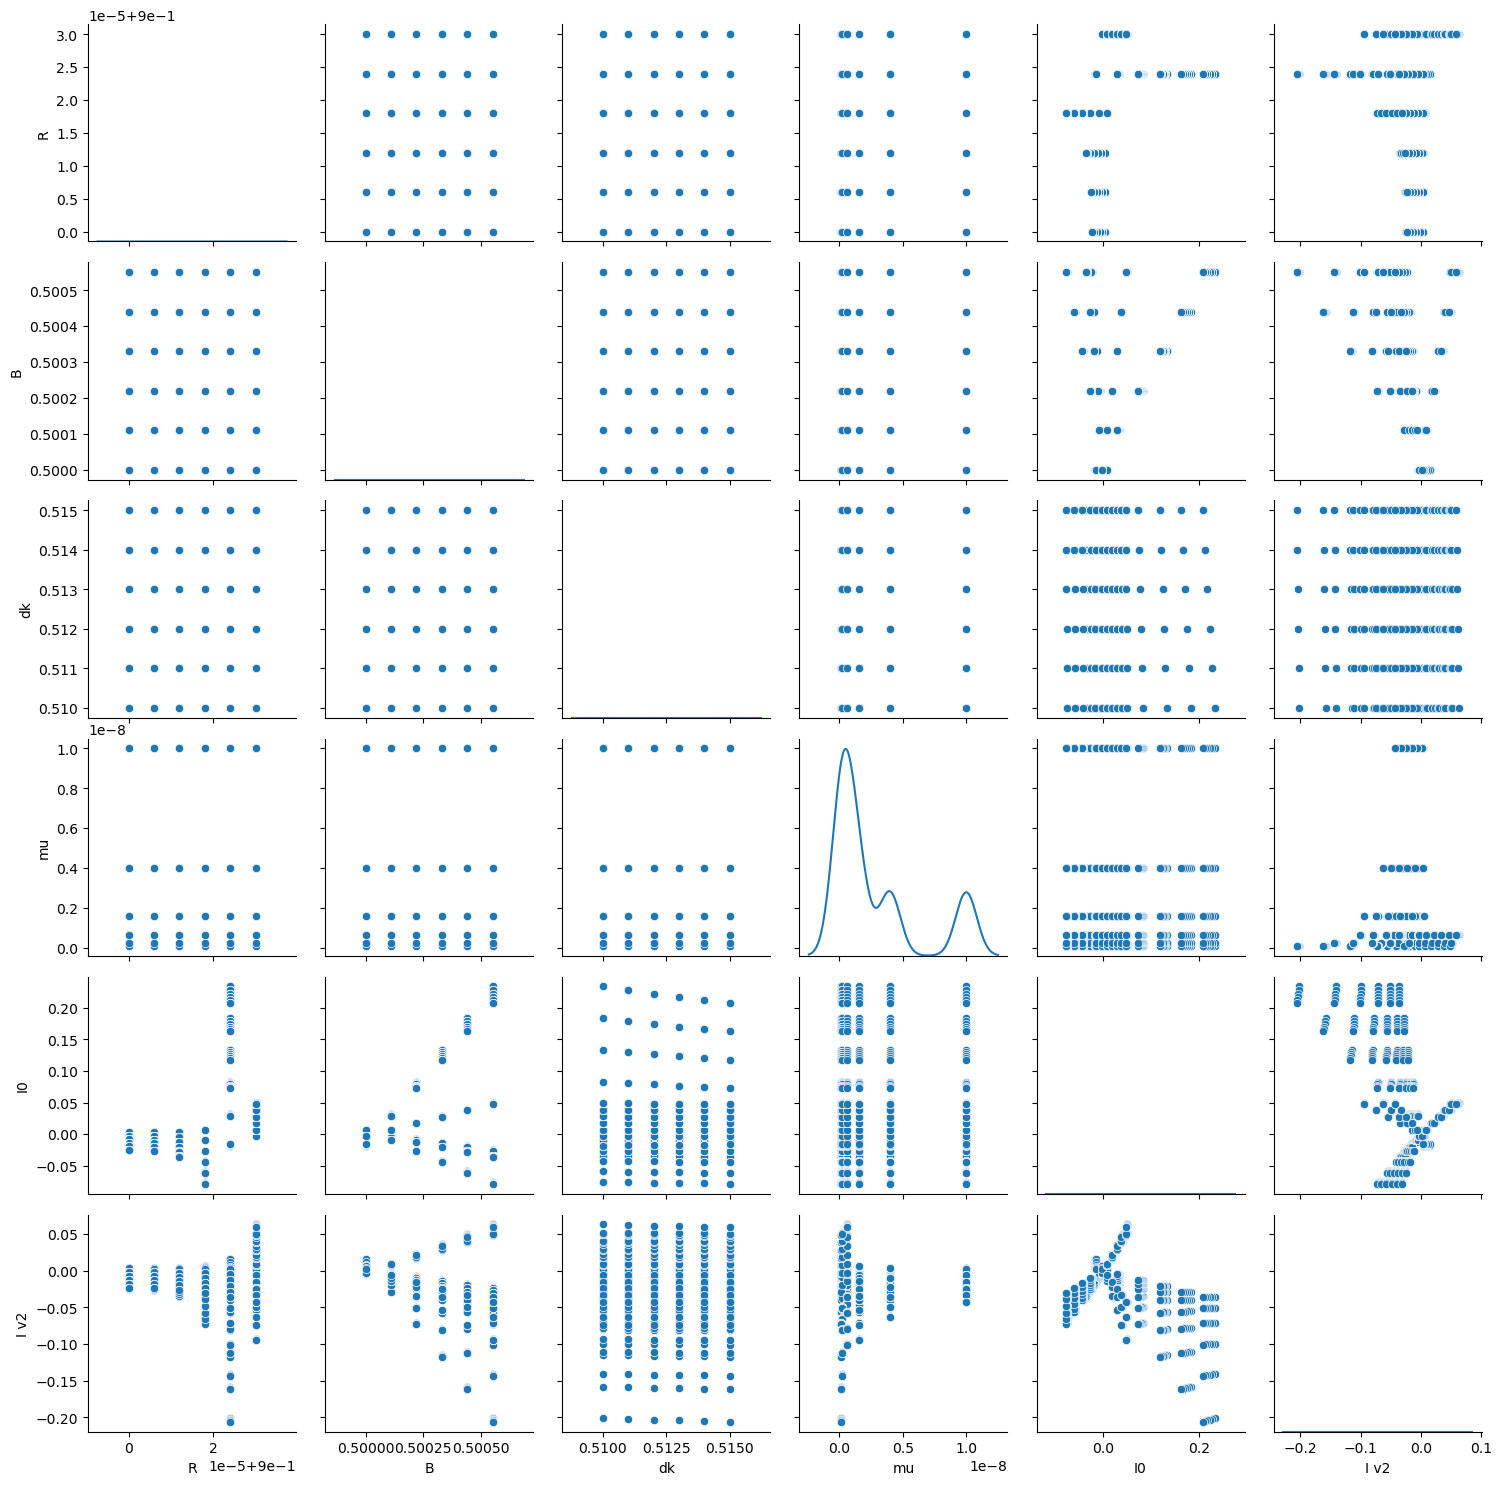

In [21]:
g = sns.PairGrid(new_tbl[["R", "B", "dk", "mu", "I0", "I v2"]])

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)

$\mu$ dependence reduces the current all-around for larger $\mu$ values. dk changes here are too sensitive, and the change is not visible at all at this level of change. $B$ changes are approximated by a first order Taylor expansion -- the changes here are noticable, but linearized. The first derivative is not small, but we are still in the linearized regime.

Potential paths for analysis:
 1) Redo the grid for points with better spacing.
 2) Freeze $R$ and analyze dependence on only the other parameters. My understanding of the old current dependence is that $R$ dependence is more complex, but coupled with other dependencies. $\mu$ appears to cause a rotation of my functions as well as a reduction of amplitude. If the coupling is unchanged, in theory determining $B$, dk and $\mu$ dependence is enough for deciphering the $R$ dependence
 3) Monte Carlo gathering of points and a regression to a postulated functional form. 

The $I0$ vs "$I$ v2" graph looks like there is a rotation. Specifically, $R$ is causing the remaining pattern to rotate and rescale. The fact that it is specifically $R$ which is causing the wildly differing data spread will be seen later.

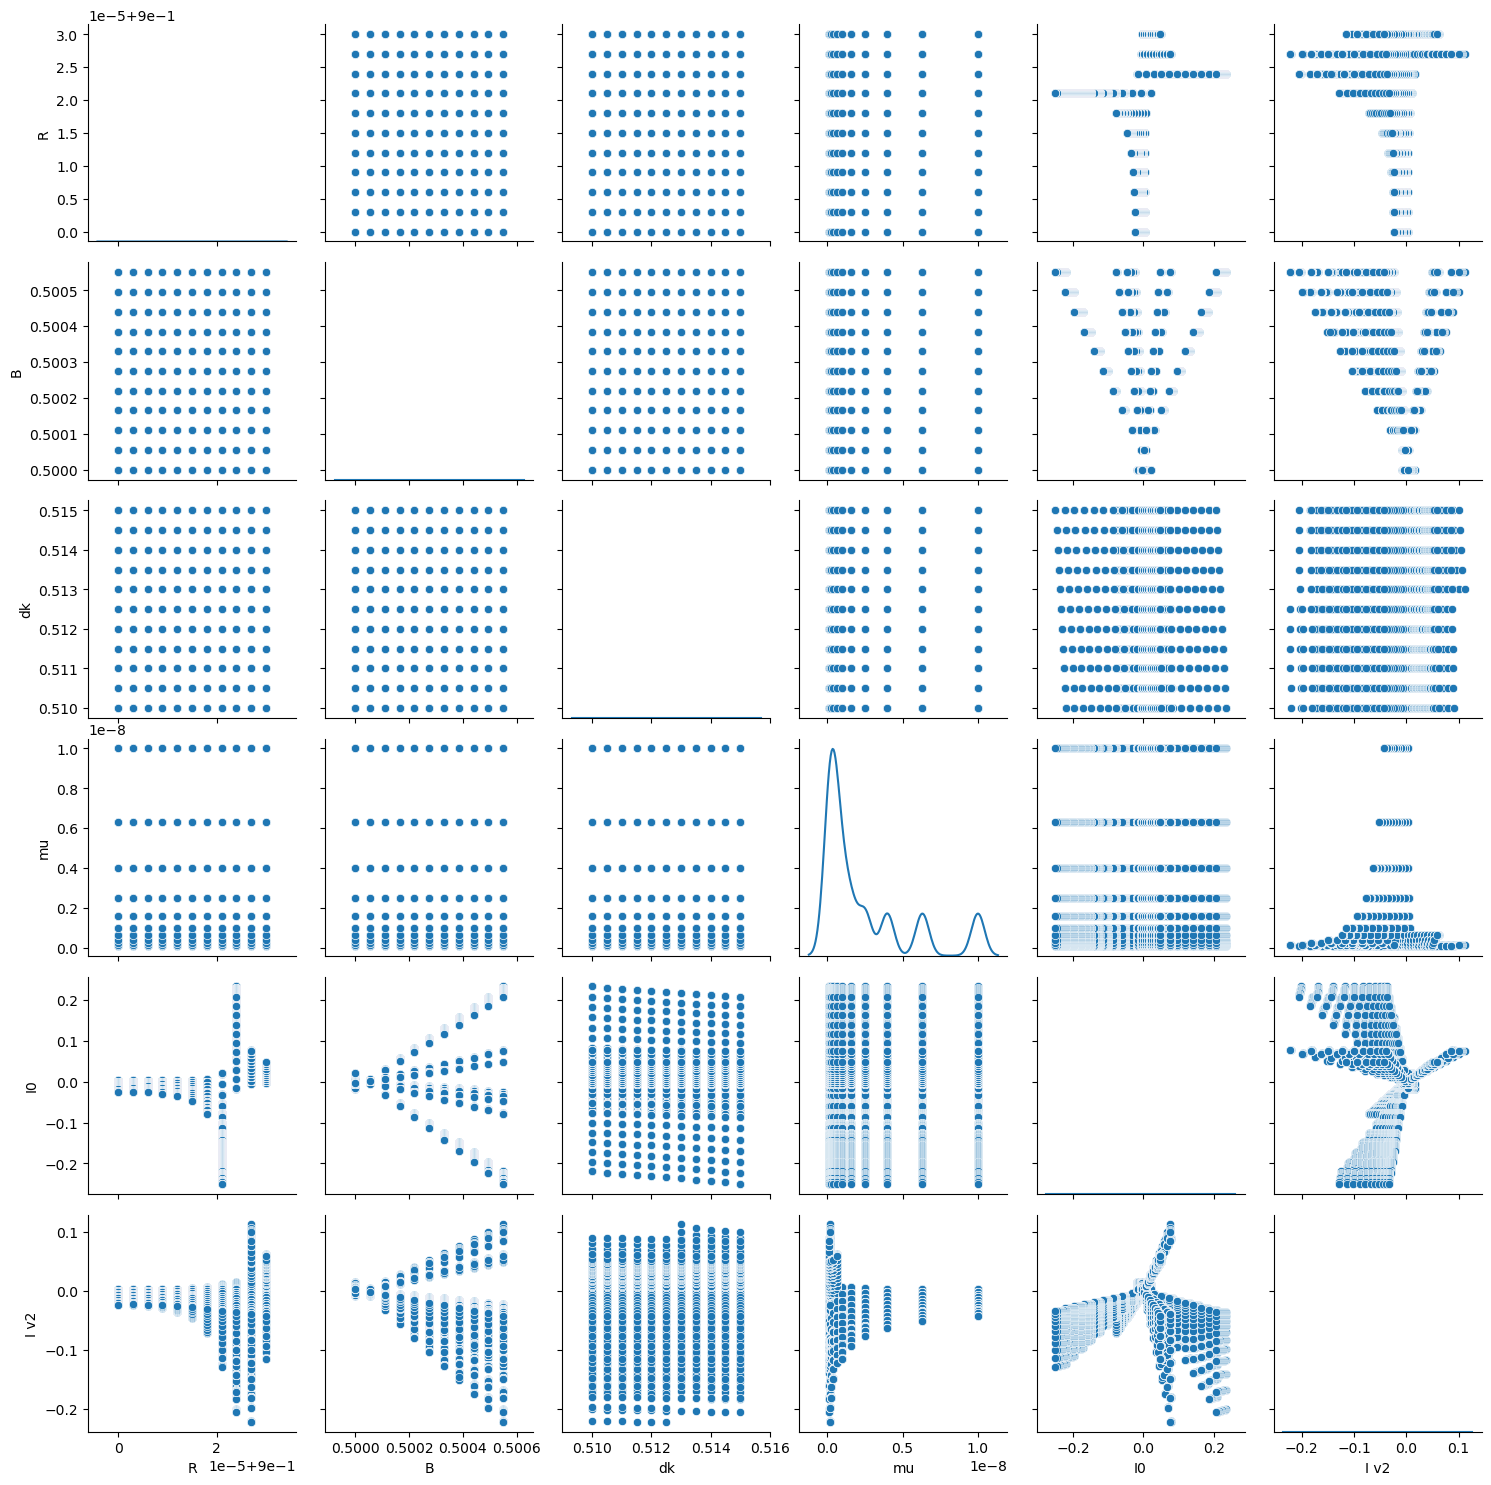

In [22]:
g = sns.PairGrid(tbl021[["R", "B", "dk", "mu", "I0", "I v2"]])

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)

This is the same data set as the previous graph, just now with more points. I see a dk vs "I v2" jump, which I didn't see previously.

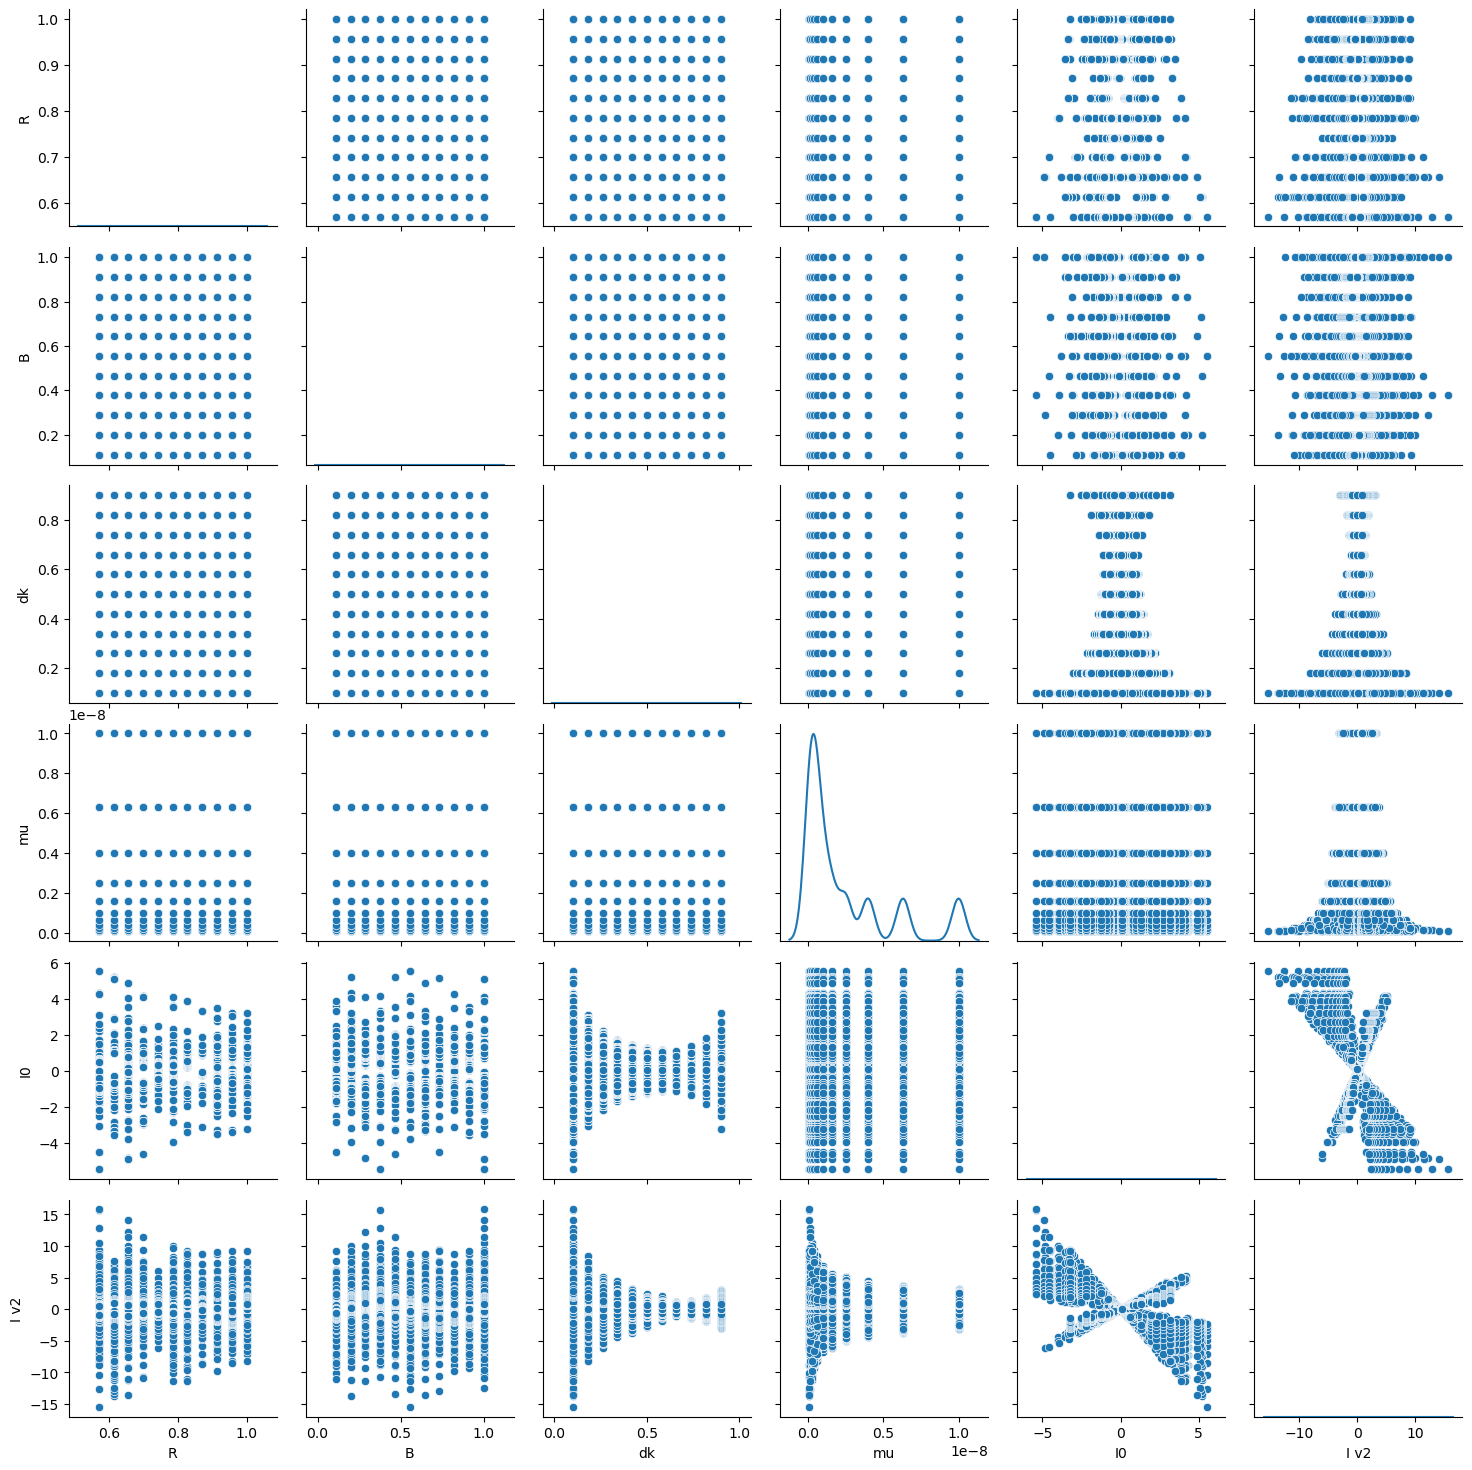

In [23]:
g = sns.PairGrid(tbl023[["R", "B", "dk", "mu", "I0", "I v2"]])

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)

As expected, analyzing the results for large changes in $R and $B$ just causes confusion. $\mu$ dependence and $dk$ dependence are quite clear here. $\mu$ appears to be reducing the amplitude of the current. 

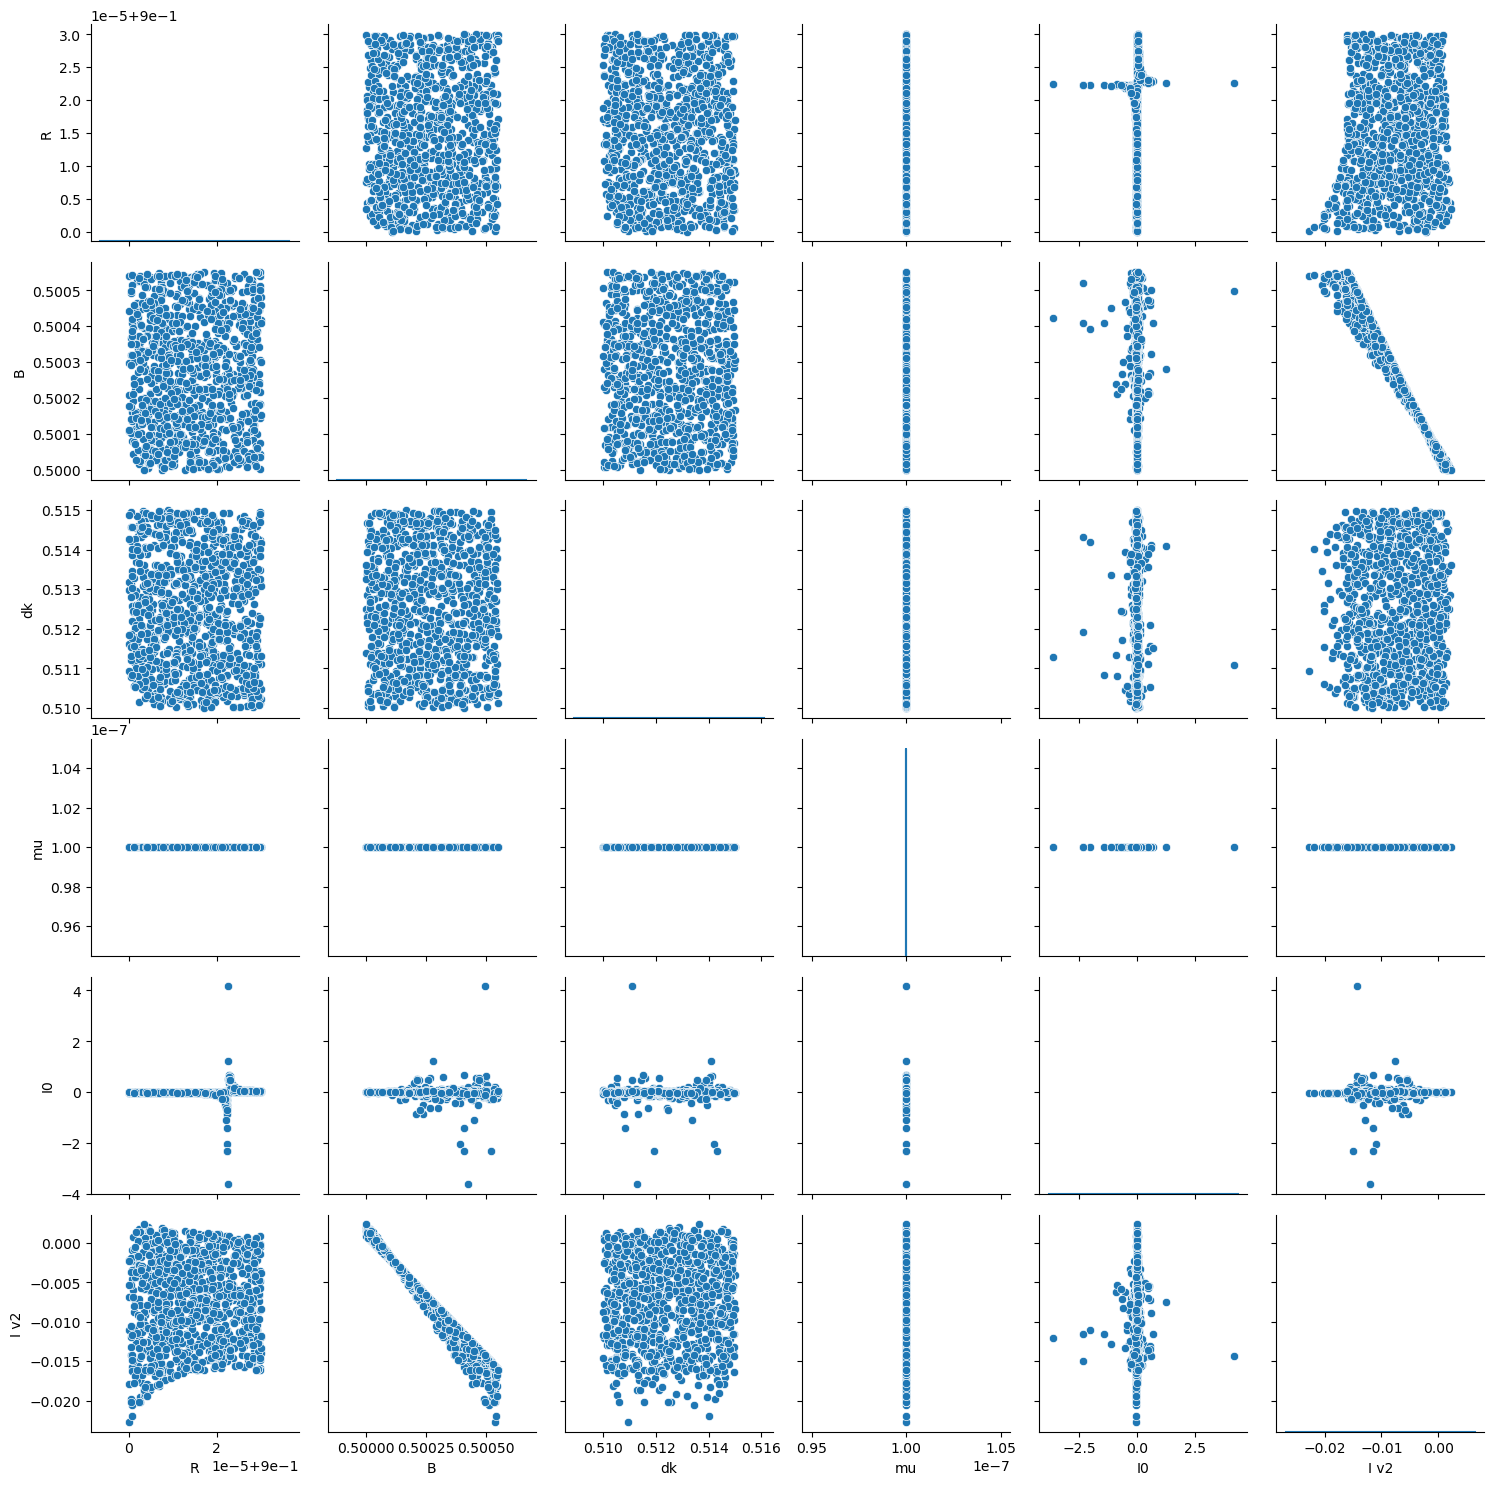

In [51]:
g = sns.PairGrid(tbl025[["R", "B", "dk", "mu", "I0", "I v2"]])

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)

The Monte Carlo analysis has an error. $\mu$ is fixed here at $10^{-7}$. This was not intended. Certain shapes and patterns are visible here. $B$ dependence is linear (or rather linearized). $R$ dependence of I0 shows a divergence. My choices of $B$ and $R$ appear to be significant with respect to the part of the periodic behavior they show. 

# Fixed $R$ Analysis

My first attempt at analysis fixed $R$ and attempted to analyze the other parameters from the grid with small parameter variations. $R$ is the most difficult of the parameters to analyze, so I removed it to try to decipher the other dependencies. Note that I expected the form to be similar, but not identical, to the case without ee interaction. (It turns out to be identical.) Here I retain the graphs, but none of the analysis (as it is obsolite). 

In [24]:
R_val = 0.900018 * 1.0e-6
tbl031 = tbl021[tbl021["R"]== 0.900018]

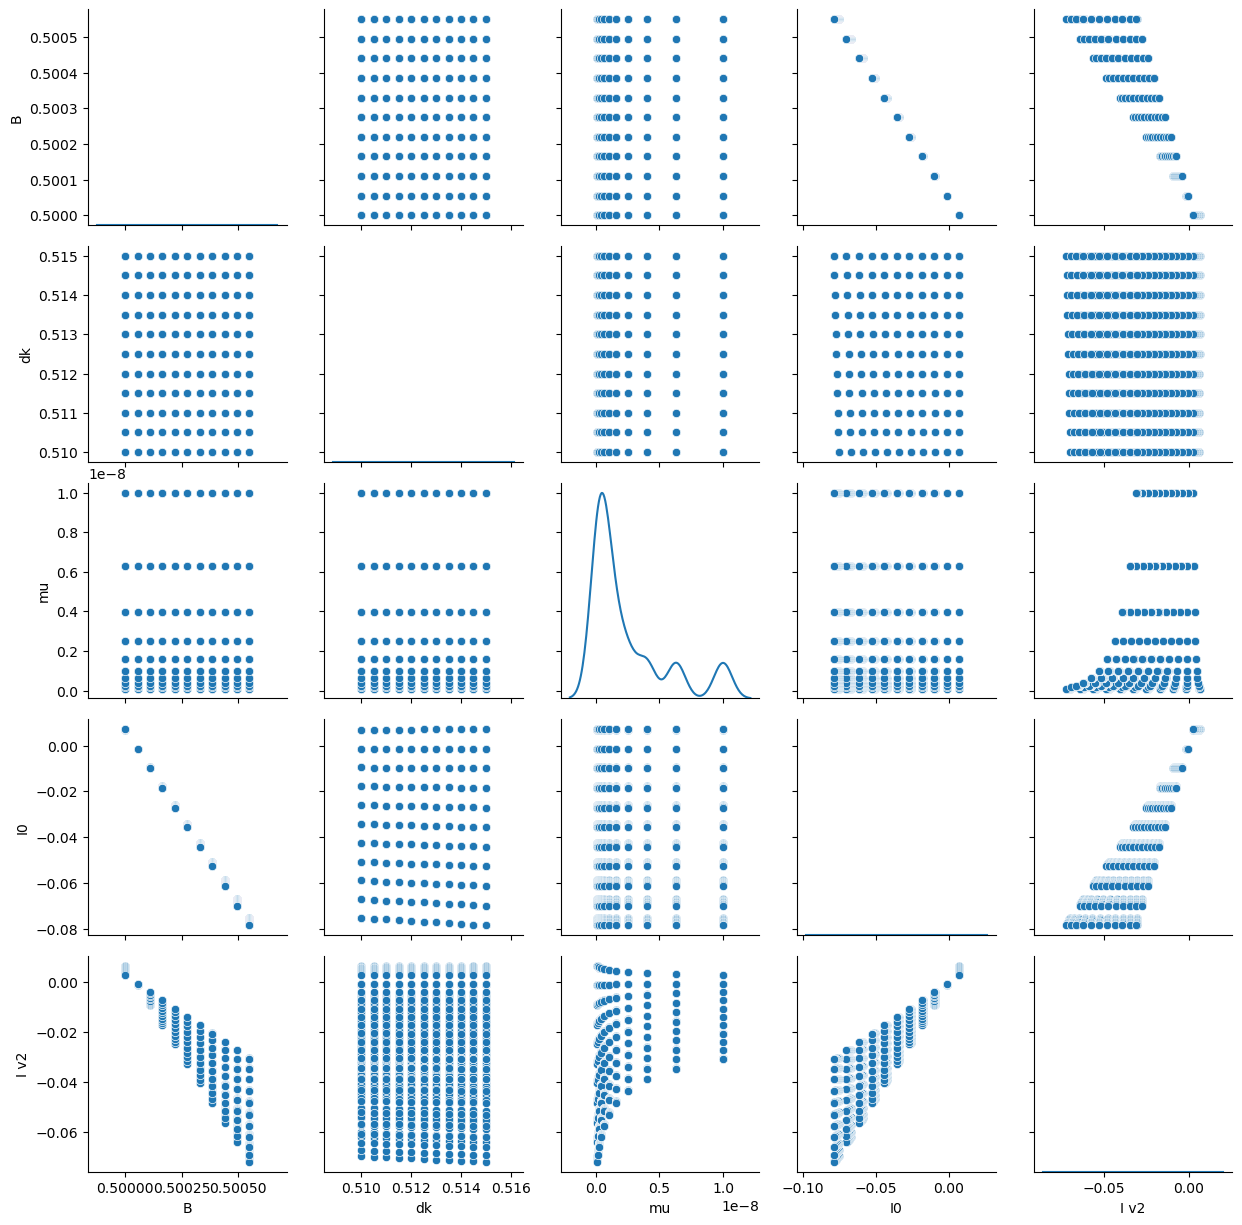

In [25]:
g = sns.PairGrid(tbl031[["B", "dk", "mu", "I0", "I v2"]])

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)

My idea for the model of $I_j$  is to use the old $I_j$ calculations, defining a phase shift given by the change in $k$ and $M$, and then adding a power-law squeezing of the current based on $\mu$. The squashing and rotation are clearly visible on the plots, with the squashing being visible even with the rapid rotation. I want to start with the predicted changes of $k$ and $M$ to guess my phase shift as everything appears to be based on this change, and I know that they will produce a phase shift. I should probably look not just power-law decay for $\mu$. I am not quite sure why I just jumped to power law. Possibly because power laws are typical of emergent behavior.

# Predicting Functional Form

Now to add our model to our table and see how well it predicts our results. Our model is,
\begin{equation}
I_j = - \frac{\sin\left(2 \pi M_j R_j\right)}{\sin\left(2 \pi k_j R_j\right)}
\end{equation}

In [26]:
# Lets predict a model which looks like the model without ee interaction, and see if this provides
# an easier starting point for regression.
# Note that R and B are here both a percent of their maximum value, not in SI units.

def func_cur_ee(R, B, dk, mu, dpsi0, A = 1., k = eelib.kFAu):
    R = R * R_max
    B = B * B_max
    k_new = eelib.pred_fast_k_true(dpsi0, mu, dk, B, R, A=A, k0=k)
    M_new = eelib.pred_slow_k_v3(dpsi0, mu, dk, B, R, A=A, k0=k)
    
    ret_val = - np.sin(2*pi*R*M_new)/np.sin(2*pi*R*k_new)

    return ret_val

And for the linear case, 
\begin{equation}
I_j = - \frac{\sin\left(2 \pi M_0 R_j\right)}{\sin\left(2 \pi k_0 R_j\right)}
\end{equation}

In [ ]:
# Our known solution for the linear case. 
# Note that R and B are here both a percent of their maximum value, not in SI units.

def func_cur(R, B, k, dk):
    R = R * R_max
    B = B * B_max
    ret_val = - np.sin(2*pi*R*R*B*phi0inv)/np.sin(2*pi*R*(k+dk/2/R_max))
    return ret_val

I had an error in my code, so in order to try to fix it, I tried to develop an alternative equation for calculating current, in order to try to reduce numerical error. It is derived as follows. I know that $a_j+b_j = \psi(0)$ which is set to $1$. I also know that $I_j = |a_j|^2-|b_j|^2$. So,
\begin{equation}
a_j-b_j = \bar{\psi}_j(0) * (a_j-b_j) =(\bar{a}_j+\bar{b}_j)(a_j-b_j) =|a_j|^2-|b_j|^2 +\bar{a}_jb_j-a_j\bar{b}_j = I - \bar{a}_j(1-a_j)+a(1-\bar{a}_j) = I + 2 i \, \mathrm{Im} (a_j).
\end{equation}
We can also derive an equation for $a_j-b_j$ from the derivative of $\psi_j$. 
\begin{equation}
\psi_j^\prime(x) = i a_j (k_j+M_j) e^{i (k_j+M_j) x} + i b_j (M_j-_jk) e^{i (M_j-k_j) x} 
\end{equation}
or for $x=0$,
\begin{equation}
\psi_j^\prime(0) = i M_j + i k_j \left( a_j - b_j \right).
\end{equation} 
So,
\begin{equation}
a_j-b_j = 2a_j-1 = \frac{\psi_j^\prime(0) - i M_j}{ik_j}
\end{equation}
and
\begin{equation}
a_j = - i \frac{\psi_j^\prime(0)}{2 k_j}-\frac{M_j}{2 k_j}+\frac{1}{2}.
\end{equation}
Putting everything together gives
\begin{equation}
I_j = \frac{\mathrm{Im} \left(\psi_j^\prime(0)\right)}{k_j} - \frac{M_j}{k_j}
\end{equation}

In [ ]:
# New current calculation.
def func_cur_from_deriv(dpsi0, M, k):
    return np.imag(dpsi0)/k-M/k

Now to add these to the table.

In [36]:
# Code for adding columns to a table with the predictions for
# I0 and I. 
def predict_table(table, k_val=eelib.kFAu, A_val=1.0):
    # Find out how many rows we have.
    no_samp = len(table.index)

    # Storage arrays, preallocate our space
    pred_vals = np.zeros(no_samp) # prediction for I0 
    cur_vals = np.zeros(no_samp)    # our new calculation for I0
    pred_vals_new = np.zeros(no_samp) # prediction for I, using the same formula as for I0, but with new values of k and M

    # Our parameter values.
    r_v = table["R"].to_numpy()
    b_v = table["B"].to_numpy()
    dk_v = table["dk"].to_numpy()
    dpsi0_v = table["dpsi0"].to_numpy()
    mu_v = table["mu"].to_numpy()
    dpsi_v = table["dpsi"].to_numpy()

    # Our M and k for the linear case.
    m_v = b_v * r_v * B_max * R_max * phi0inv
    k_v = k_val + dk_v /2.0/R_max

    # Fill our storage arrays from the relevant functions.
    for i in range(no_samp):
        pred_vals[i] = func_cur(r_v[i], b_v[i], k_val, dk_v[i])
    for i in range(no_samp):
        cur_vals[i]=func_cur_from_deriv(dpsi0_v[i], m_v[i], k_v[i])
    for i in range(no_samp):
        pred_vals_new[i] = func_cur_ee(r_v[i], b_v[i], dk_v[i], mu_v[i], dpsi_v[i])

    # Add the columns to the table.
    table["I0 p1"] = cur_vals
    table["I0 p2"] = pred_vals
    table["I pred"] = pred_vals_new

In [37]:
predict_table(tbl021)

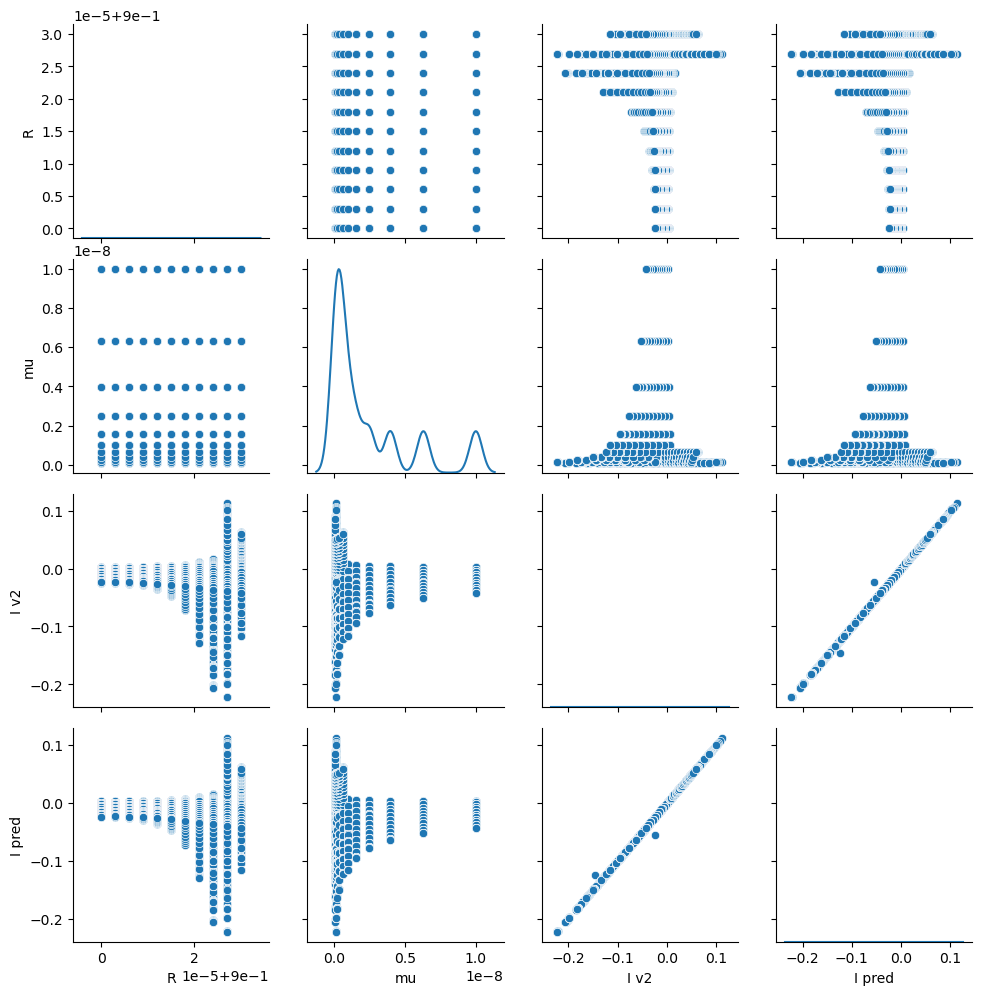

In [ ]:
# Here are my triangle plots to compare the predicted and calculated values.
# I have a result of a line with a slope of 1, ie my guess is correct, not just proportional.
# There are a few outliers visible on the graph.
g = sns.PairGrid(tbl021[["R",'mu',"I v2","I pred"]])

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)

And the model clearly shows not just a linear relationship, but rather that we completely predicted the result. This should have been obvious from the matching condition, but here it is clear. I will continue to check these results, to show how good the results are. Here is our measure of our fit.

In [39]:
# The variable names are from sklearn typical variable naming.
# since I am bad at naming variables.

# results from numerical calculation
y_test = tbl021["I v2"].to_numpy()   
# predicted model -- as the case without ee interaction, but with the new k and M values
y_pred = tbl021["I pred"].to_numpy() 

# For these estimates, I need enough decimal places for the error to be seen.

r2 = r2_score(y_test, y_pred)
print(f"R2:   {r2:.7f}")

mse = mean_squared_error(y_test, y_pred)
print(f"MSE:  {mse:.7f}")

rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.7f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE:  {mae:.7f}")

# This is not the correct metric for this measure, but still gives a decent
# understanding of how far the points can diverge from the plot. 
# Based on the other measures, these points are most likely erroneous.
# I know the error in the calculated current can be large.
max_val = np.max([np.max(y_test), np.max(y_pred)])
max_sep = np.max(y_test-y_pred)
print(f"Estimate maximum error: {max_sep/max_val}")

R2:   0.9998840
MSE:  0.0000001
RMSE: 0.0003233
MAE:  0.0000038
Estimate maximum error: 0.2835049216758385


Now lets try for our other datasets.

In [40]:
predict_table(tbl023)

In [41]:
tbl023.head()

,R,B,dk,mu,dpsi0,a0,b0,A max 0,I0,dpsi,a,b,A max new,I v2,effective mu,I0 p1,I0 p2,I pred
0,0.57,0.11,0.1,1.000000e-10,-1.068926e+11-5.376625e+ 10j,-1.740277+4.453840j,2.740277-4.453840j,10.011085,-4.480554,2.249675e+11+1.115203e+ 11j,5.146633-9.373606j,-4.146633+9.373606j,20.943396,9.293266,4.386258e-08,-4.480554,-4.480554,9.293387
1,0.57,0.11,0.1,1.584893e-10,-1.068926e+11-5.376625e+ 10j,-1.740277+4.453840j,2.740277-4.453840j,10.011085,-4.480554,1.847757e+11+9.159280e+ 10j,4.316325-7.698956j,-3.316325+7.698956j,17.209193,7.632650,4.693761e-08,-4.480554,-4.480554,7.632756
2,0.57,0.11,0.1,2.511886e-10,-1.068926e+11-5.376625e+ 10j,-1.740277+4.453840j,2.740277-4.453840j,10.011085,-4.480554,1.522990e+11+7.549034e+ 10j,3.645392-6.345764j,-2.645392+6.345764j,14.193394,6.290784,5.060256e-08,-4.480554,-4.480554,6.290878
3,0.57,0.11,0.1,3.981072e-10,-1.068926e+11-5.376625e+ 10j,-1.740277+4.453840j,2.740277-4.453840j,10.011085,-4.480554,1.259541e+11+6.243197e+ 10j,3.101296-5.248064j,-2.101296+5.248064j,11.749025,5.202591,5.495455e-08,-4.480554,-4.480554,5.202676
4,0.57,0.11,0.1,6.309573e-10,-1.068926e+11-5.376625e+ 10j,-1.740277+4.453840j,2.740277-4.453840j,10.011085,-4.480554,1.044921e+11+5.180113e+ 10j,2.658346-4.353821j,-1.658346+4.353821j,9.760186,4.316691,6.010578e-08,-4.480554,-4.480554,4.316768


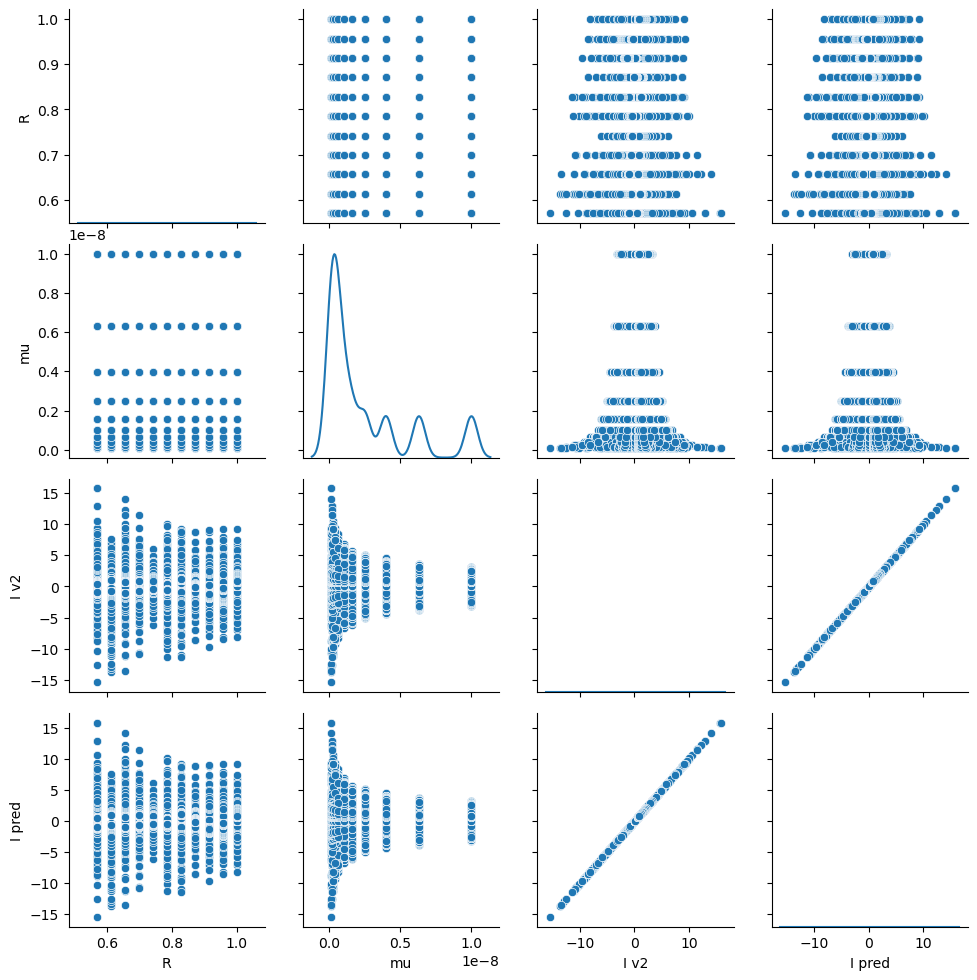

In [42]:
g = sns.PairGrid(tbl023[["R",'mu',"I v2","I pred"]])

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)

And for testing our goodness of fit.

In [43]:
# The variable names are from sklearn typical variable naming.
# since I am bad at naming variables.

# results from numerical calculation
y_test = tbl023["I v2"].to_numpy()   
# predicted model -- as the case without ee interaction, but with the new k and M values
y_pred = tbl023["I pred"].to_numpy() 

# For these estimates, I need enough decimal places for the error to be seen.

r2 = r2_score(y_test, y_pred)
print(f"R2:   {r2:.7f}")

mse = mean_squared_error(y_test, y_pred)
print(f"MSE:  {mse:.7f}")

rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.7f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE:  {mae:.7f}")

# This is not the correct metric for this measure, but still gives a decent
# understanding of how far the points can diverge from the plot. 
# Based on the other measures, these points are most likely erroneous.
# I know the error in the calculated current can be large.
max_val = np.max([np.max(y_test), np.max(y_pred)])
max_sep = np.max(y_test-y_pred)
print(f"Estimate maximum error: {max_sep/max_val}")

R2:   0.9999993
MSE:  0.0000019
RMSE: 0.0013798
MAE:  0.0001261
Estimate maximum error: 0.0030560971707368875


And for the Monte Carlo dataset.

In [44]:
df = tbl025
predict_table(df)

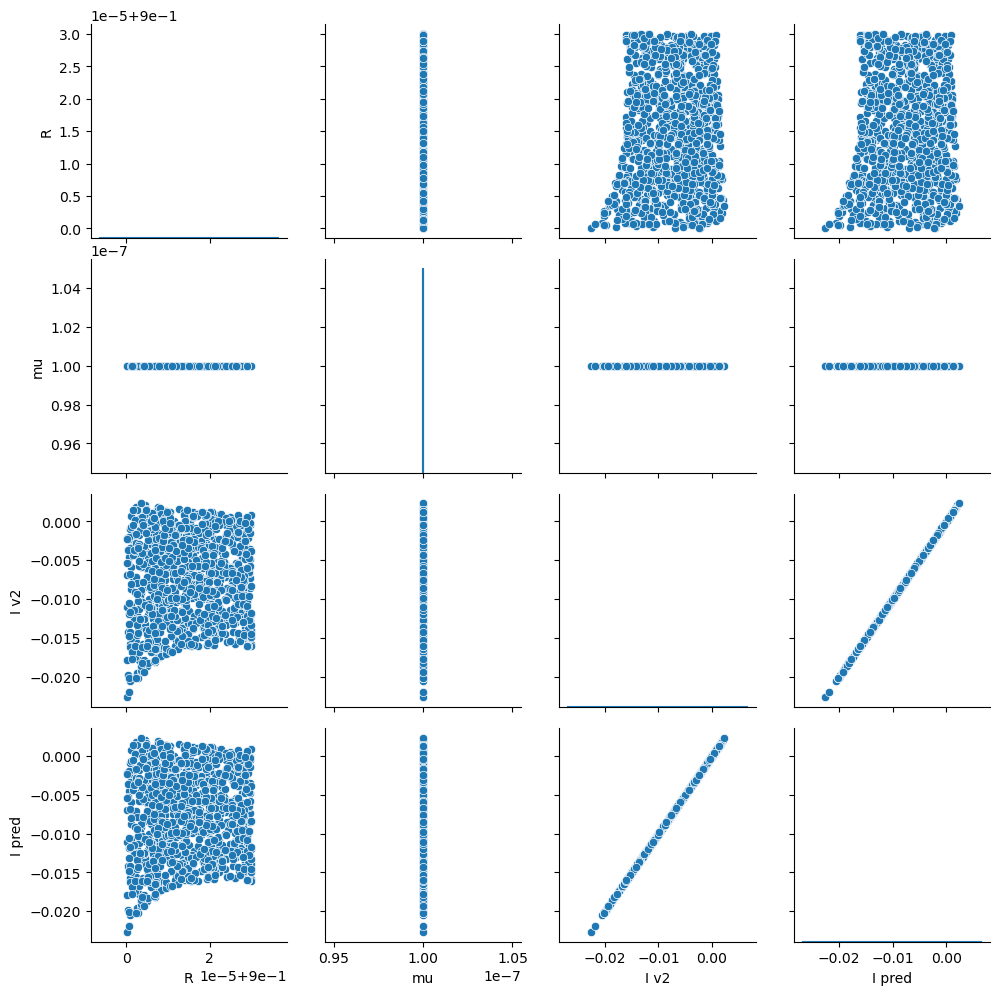

In [45]:
g = sns.PairGrid(df[["R",'mu',"I v2","I pred"]])

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)

In [46]:

# The variable names are from sklearn typical variable naming.
# since I am bad at naming variables.

# results from numerical calculation
y_test = df["I v2"].to_numpy()   
# predicted model -- as the case without ee interaction, but with the new k and M values
y_pred = df["I pred"].to_numpy() 

# For these estimates, I need enough decimal places for the error to be seen.

r2 = r2_score(y_test, y_pred)
print(f"R2:   {r2:.7f}")

mse = mean_squared_error(y_test, y_pred)
print(f"MSE:  {mse:.7f}")

rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.7f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE:  {mae:.7f}")

# This is not the correct metric for this measure, but still gives a decent
# understanding of how far the points can diverge from the plot. 
# Based on the other measures, these points are most likely erroneous.
# I know the error in the calculated current can be large.
max_val = np.max([np.max(y_test), np.max(y_pred)])
max_sep = np.max(y_test-y_pred)
print(f"Estimate maximum error: {max_sep/max_val}")

R2:   1.0000000
MSE:  0.0000000
RMSE: 0.0000002
MAE:  0.0000001
Estimate maximum error: 0.00038383139285069875


This is definitely the correct equation.

# Test a, b

The last analysis of this notebook is to check that $a_j$ and $b_j$ have the same form as the linear case, just with new $k_j$ and $M_j$ values.

In [47]:
# The linear model for a and b.
# Requires k, M = BR pi / Phi_0, and R.
# Returns a_j, b_j.
def ab_pred(k, M, R):
    denom = 2j*np.sin(2*pi*k*R)*np.exp(2j*M*2*pi*R)
    a_num = 1 - np.exp(1j*2*pi*R*(-k+M))
    b_num = -1 + np.exp(1j*2*pi*R*(k+M))
    return a_num / denom, b_num / denom

In [48]:
# The nonlinear model for a and b.
# It is the same as the linear model, but with new k_j and M_j values.
# Requires R, B, dk, mu, dpsi0, A (1 by default), and k (k_Fermi for gold by default)
# Returns a_j, b_j.
def ab_pred_ee(R, B, dk, mu, dpsi0, A = 1., k = eelib.kFAu):
    R = R * R_max # rescale R
    B = B * B_max # rescale B
    k_new = eelib.k_M_models_ivp.pred_fast_k_true(dpsi0, mu, dk, B, R, A=A, k0=k) # predict k
    M_new = eelib.pred_slow_k_v3(dpsi0, mu, dk, B, R, A=A, k0=k) # predict M
    
    ret_val1, ret_val2 = ab_pred(k_new, M_new, R) # as the linear case, but with new values of k and M

    return ret_val1, ret_val2

In [49]:
# Add the predicted nonlinear a_j and b_j values to the table
def predict_table_ab(table, k_val=eelib.kFAu, A_val=1.0):

    no_samp = len(table.index) # how many rows

    pred_vals_a = np.zeros(no_samp, complex) # preallocate space
    pred_vals_b = np.zeros(no_samp, complex) # preallocate space

    # our columns of parameters
    r_v = table["R"].to_numpy()
    b_v = table["B"].to_numpy()
    dk_v = table["dk"].to_numpy()
    dpsi0_v = table["dpsi0"].to_numpy()
    mu_v = table["mu"].to_numpy()
    dpsi_v = table["dpsi"].to_numpy()

    # linear model k and M
    m_v = b_v * r_v * B_max * R_max * phi0inv
    k_v = k_val + dk_v /2.0/R_max

    # predict a_j, b_j for every row
    for i in range(no_samp):
        pred_vals_a[i], pred_vals_b[i] = ab_pred_ee(r_v[i], b_v[i], dk_v[i], mu_v[i], dpsi_v[i], A_val, k_val)

    # add rows to table
    table["ap"] = pred_vals_a
    table["bp"] = pred_vals_b

In [50]:
df = tbl021
predict_table_ab(df)

In [52]:
tbl021.head()

,R,B,dk,mu,dpsi0,a0,b0,A max 0,I0,dpsi,a,b,A max new,I v2,effective mu,I0 p1,I0 p2,I pred,ap,bp
0,0.9,0.5,0.51,1.000000e-10,1.054613e+10+4.462116e+ 07j,0.501674-0.439413j,0.498326+0.439413j,1.331292,0.003348,1.052821e+10+4.460161e+ 07j,0.501673-0.438666j,0.498327+0.438666j,1.330307,0.003346,1.769717e-10,0.003348,0.003348,0.003346,0.503126-0.436999j,0.496869+0.440317j
1,0.9,0.5,0.51,1.584893e-10,1.054613e+10+4.462116e+ 07j,0.501674-0.439413j,0.498326+0.439413j,1.331292,0.003348,1.051777e+10+4.459022e+ 07j,0.501673-0.438231j,0.498327+0.438231j,1.329733,0.003345,2.802394e-10,0.003348,0.003348,0.003345,0.503123-0.436565j,0.496871+0.439881j
2,0.9,0.5,0.51,2.511886e-10,1.054613e+10+4.462116e+ 07j,0.501674-0.439413j,0.498326+0.439413j,1.331292,0.003348,1.050128e+10+4.457225e+ 07j,0.501672-0.437544j,0.498328+0.437544j,1.328828,0.003344,4.435448e-10,0.003348,0.003348,0.003344,0.503119-0.435879j,0.496875+0.439193j
3,0.9,0.5,0.51,3.981072e-10,1.054613e+10+4.462116e+ 07j,0.501674-0.439413j,0.498326+0.439413j,1.331292,0.003348,1.047527e+10+4.454395e+ 07j,0.501671-0.436460j,0.498329+0.436460j,1.327402,0.003342,7.014631e-10,0.003348,0.003348,0.003342,0.503113-0.434797j,0.496881+0.438108j
4,0.9,0.5,0.51,6.309573e-10,1.054613e+10+4.462116e+ 07j,0.501674-0.439413j,0.498326+0.439413j,1.331292,0.003348,1.043440e+10+4.449953e+ 07j,0.501669-0.434757j,0.498331+0.434757j,1.325164,0.003338,1.107999e-09,0.003348,0.003348,0.003338,0.503103-0.433097j,0.496891+0.436402j


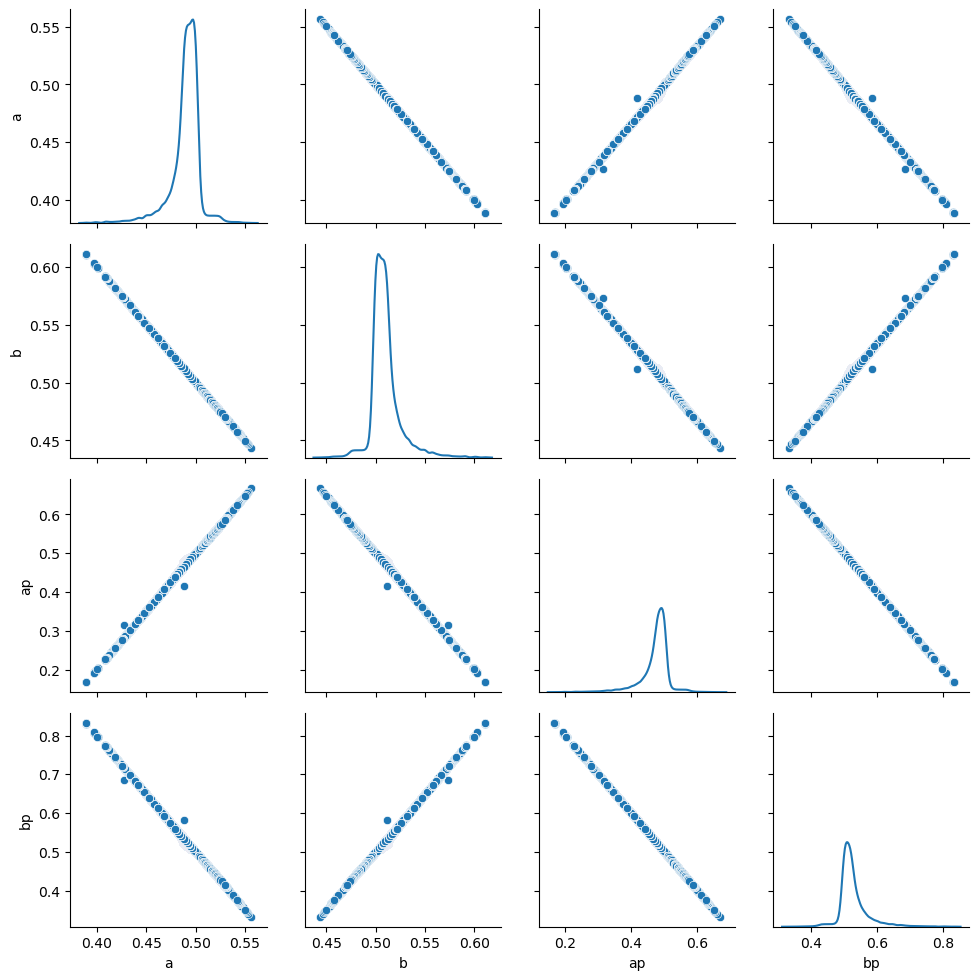

In [53]:
g = sns.PairGrid(tbl021[["a", "b", "ap", "bp"]])

with warnings.catch_warnings(action="ignore"):
    g.map_diag(sns.kdeplot)
    g.map_upper(sns.scatterplot)
    g.map_lower(sns.scatterplot)

The model is correct. Note that the plots above only show the real components of $a_j$ and $b_j$. 

$a_j+b_j = 1$, hence the inverse propotionality in the plots above between $a_j$ and $b_j$.